=== 比較実行パラメータ ===
N = 100
M_BA = 2
P_ER = None
使用した ER の p = 0.040404
ER_EXTRA_EDGE_FRAC = 0.0
ENTROPY_LOG_BASE = 2

=== BA ===
ノード数                 : 100
エッジ数                 : 196
平均次数                 : 3.9200
密度                     : 0.039596
平均クラスタ係数         : 0.163388
平均最短距離(最大連結成分): 2.852727
次数エントロピー         : 2.290220 bits
正規化 次数エントロピー  : 0.638841
構造エントロピー         : 6.138589 bits
正規化 構造エントロピー  : 0.923950
von Neumann entropy      : 5.982654 bits
正規化 von Neumann entr. : 0.900479
近接中心性エントロピー   : 6.630347 bits
正規化 近接中心性 entr.  : 0.997967
媒介中心性エントロピー   : 4.546019 bits
正規化 媒介中心性 entr.  : 0.700265

=== ER ===
ノード数                 : 100
エッジ数                 : 177
平均次数                 : 3.5400
密度                     : 0.035758
平均クラスタ係数         : 0.018500
平均最短距離(最大連結成分): 3.550687
次数エントロピー         : 2.921961 bits
正規化 次数エントロピー  : 0.879598
構造エントロピー         : 6.414887 bits
正規化 構造エントロピー  : 0.965537
von Neumann entropy      : 6.213814 bits
正規化 von Neumann entr. : 0.935272
近接中心性エントロピー   : 6.5897

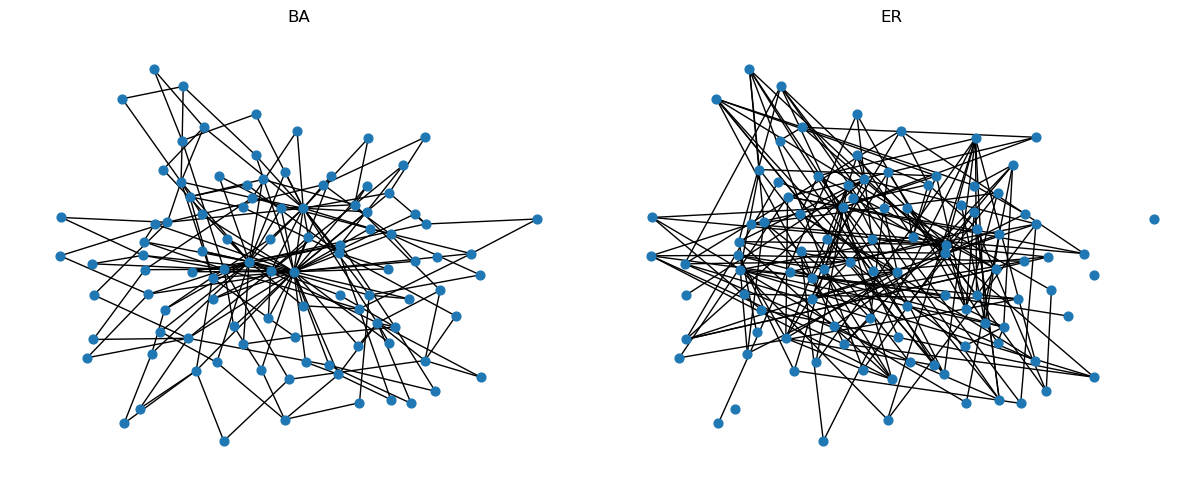

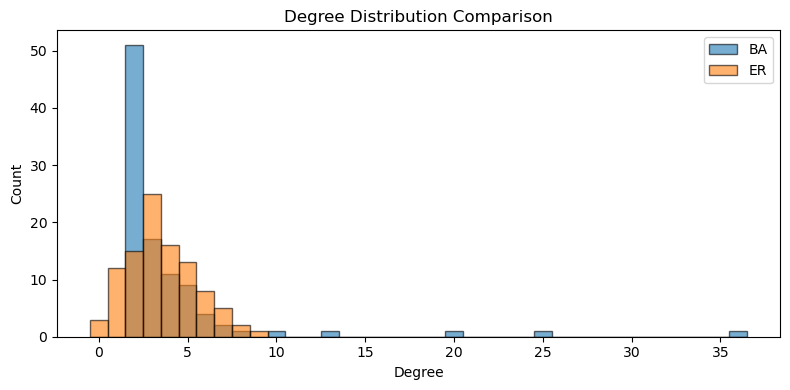

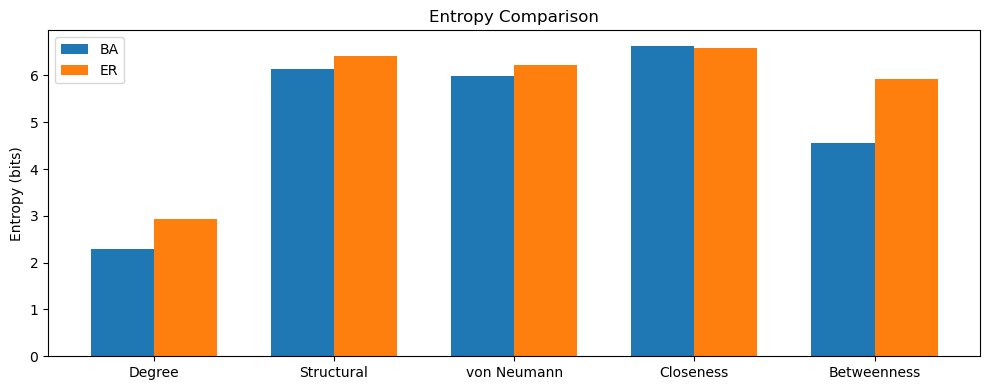

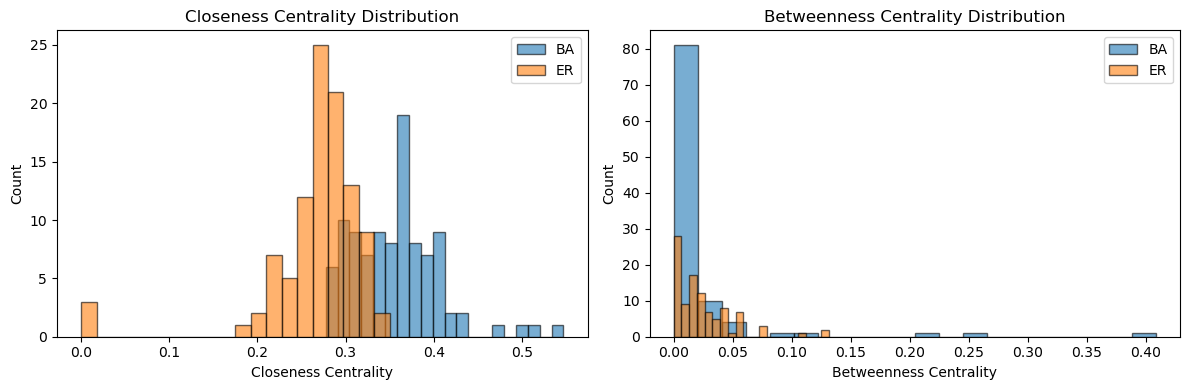

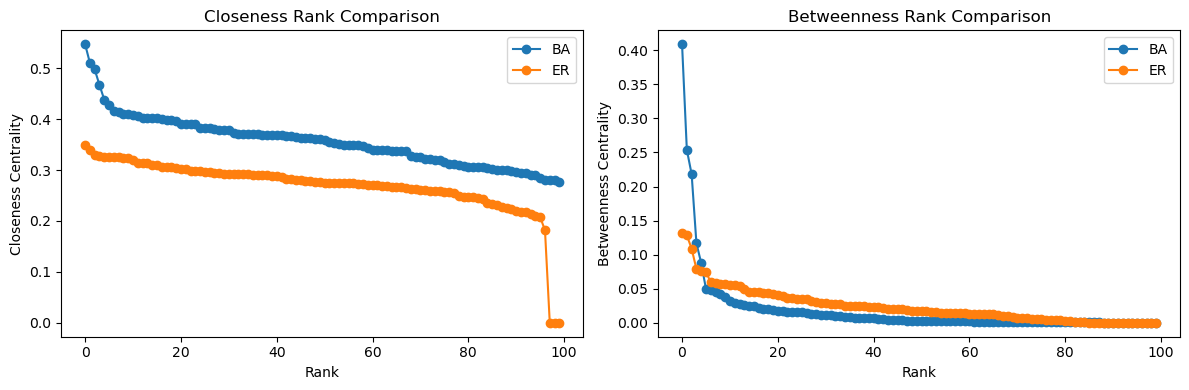

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import random


# =========================================
# 0. パラメータ（ここだけ主に調整）
# =========================================

SEED = 42

# グラフ共通
N = 100

# どのグラフを作るか
# "BA", "ER", "REGULAR"
GRAPH_TYPE = "ER"

# BA 用
M_BA = 2

# ER 用
# BA の平均次数 2*M_BA に合わせたいなら None のまま
# 自分で指定したいなら 0.05, 0.1, 0.3 などにする
P_ER = None
# P_ER = 0.3

# ER のエントロピー調整用
# 追加ランダム辺の割合（0.0 なら追加なし）
# 例: 0.2 にすると既存エッジ数の 20% 相当を追加
ER_EXTRA_EDGE_FRAC = 0.0

# 正則グラフ用
USE_REGULAR_GRAPH = False
REGULAR_DEGREE = 4

# エントロピー設定
# 2 -> bits, np.e -> nat
ENTROPY_LOG_BASE = 2

# 可視化
NODE_SIZE = 40
FIG_GRAPH = (6, 5)
FIG_HIST = (8, 4)
FIG_CENTRALITY = (12, 4)

# 比較実験
RUN_COMPARISON = True
RUN_SINGLE_GRAPH = False


# =========================================
# 1. 基本ユーティリティ
# =========================================
def get_log_fn(base):
    if base == 2:
        return np.log2
    elif base == np.e:
        return np.log
    else:
        return lambda x: np.log(x) / np.log(base)


def entropy_unit_name(base):
    if base == 2:
        return "bits"
    elif base == np.e:
        return "nat"
    else:
        return f"log base {base}"


def normalize_probabilities(values):
    arr = np.array(values, dtype=float)

    if len(arr) == 0:
        return np.array([], dtype=float)

    arr = np.where(np.isfinite(arr), arr, 0.0)
    arr = np.maximum(arr, 0.0)

    total = arr.sum()
    if total <= 0:
        return np.zeros(len(arr), dtype=float)

    return arr / total


def entropy_from_probability_vector(p, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    p = np.array(p, dtype=float)
    p = p[np.isfinite(p)]
    p = p[p > 0]

    if len(p) == 0:
        return 0.0, 0.0

    H = -np.sum(p * log_fn(p))
    H_norm = H / log_fn(len(p)) if len(p) > 1 else 0.0
    return H, H_norm


# =========================================
# 2. グラフ生成
# =========================================
def calc_default_p_er(n, m_ba):
    return (2 * m_ba) / (n - 1)


def add_random_edges(G, extra_frac=0.0, seed=42):
    if extra_frac <= 0:
        return G

    rng = random.Random(seed)
    G = G.copy()

    current_edges = G.number_of_edges()
    add_count = int(current_edges * extra_frac)

    nodes = list(G.nodes())
    tried = 0
    added = 0
    max_trials = max(1000, add_count * 20)

    while added < add_count and tried < max_trials:
        u = rng.choice(nodes)
        v = rng.choice(nodes)
        tried += 1

        if u == v:
            continue
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    return G


def generate_ba_graph(n=N, m=M_BA, seed=SEED):
    return nx.barabasi_albert_graph(n=n, m=m, seed=seed)


def generate_er_graph(n=N, p=None, m_ba=M_BA, extra_edge_frac=ER_EXTRA_EDGE_FRAC, seed=SEED):
    if p is None:
        p = calc_default_p_er(n, m_ba)

    G = nx.erdos_renyi_graph(n=n, p=p, seed=seed)
    G = add_random_edges(G, extra_frac=extra_edge_frac, seed=seed)
    return G, p


def generate_regular_graph(n=N, d=REGULAR_DEGREE, seed=SEED):
    if (n * d) % 2 != 0:
        raise ValueError("random_regular_graph では n*d が偶数である必要があります。")
    return nx.random_regular_graph(d=d, n=n, seed=seed)


def generate_graph_by_type(graph_type=GRAPH_TYPE):
    if graph_type == "BA":
        G = generate_ba_graph()
        meta = {"graph_type": "BA", "p_er": None}
    elif graph_type == "ER":
        G, p_used = generate_er_graph()
        meta = {"graph_type": "ER", "p_er": p_used}
    elif graph_type == "REGULAR":
        G = generate_regular_graph()
        meta = {"graph_type": "REGULAR", "p_er": None}
    else:
        raise ValueError("GRAPH_TYPE は 'BA', 'ER', 'REGULAR' のいずれかにしてください。")

    return G, meta


# =========================================
# 3. エントロピー
# =========================================
def degree_entropy(G, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    degrees = [d for _, d in G.degree()]
    count = Counter(degrees)
    n_nodes = sum(count.values())

    p = np.array([c / n_nodes for c in count.values()], dtype=float)

    if len(p) == 0:
        return 0.0, 0.0, degrees, count

    H = -np.sum(p * log_fn(p))
    H_norm = H / log_fn(len(p)) if len(p) > 1 else 0.0

    return H, H_norm, degrees, count


def structural_entropy(G, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    degrees = np.array([d for _, d in G.degree()], dtype=float)
    volume = degrees.sum()

    if volume <= 0:
        return 0.0, 0.0, np.zeros(len(degrees))

    p = degrees / volume
    p_nonzero = p[p > 0]

    H = -np.sum(p_nonzero * log_fn(p_nonzero))
    H_norm = H / log_fn(len(degrees)) if len(degrees) > 1 else 0.0

    return H, H_norm, p


def von_neumann_entropy(G, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    n = G.number_of_nodes()
    if n == 0:
        return 0.0, 0.0, np.array([])

    A = nx.to_numpy_array(G, dtype=float)
    deg = A.sum(axis=1)
    L = np.diag(deg) - A

    trL = np.trace(L)
    if trL <= 0:
        return 0.0, 0.0, np.array([])

    rho = L / trL

    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.real(eigvals)
    eigvals = eigvals[eigvals > 1e-12]

    if len(eigvals) == 0:
        return 0.0, 0.0, eigvals

    H = -np.sum(eigvals * log_fn(eigvals))
    H_norm = H / log_fn(n) if n > 1 else 0.0

    return H, H_norm, eigvals


def closeness_entropy(G, base=ENTROPY_LOG_BASE):
    closeness_dict = nx.closeness_centrality(G)
    closeness_vals = np.array(list(closeness_dict.values()), dtype=float)

    p = normalize_probabilities(closeness_vals)
    H, H_norm = entropy_from_probability_vector(p, base=base)

    return H, H_norm, closeness_vals, p


def betweenness_entropy(G, base=ENTROPY_LOG_BASE):
    betweenness_dict = nx.betweenness_centrality(G, normalized=True)
    betweenness_vals = np.array(list(betweenness_dict.values()), dtype=float)

    p = normalize_probabilities(betweenness_vals)
    H, H_norm = entropy_from_probability_vector(p, base=base)

    return H, H_norm, betweenness_vals, p


# =========================================
# 4. 基本統計
# =========================================
def graph_basic_stats(G):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    degrees = np.array([d for _, d in G.degree()], dtype=float)

    avg_degree = degrees.mean() if len(degrees) > 0 else 0.0
    density = nx.density(G) if n > 1 else 0.0
    clustering = nx.average_clustering(G) if n > 0 else 0.0

    if n > 0 and e > 0:
        if nx.is_connected(G):
            avg_shortest_path = nx.average_shortest_path_length(G)
            giant_ratio = 1.0
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            G_cc = G.subgraph(largest_cc).copy()
            avg_shortest_path = nx.average_shortest_path_length(G_cc)
            giant_ratio = G_cc.number_of_nodes() / n
    else:
        avg_shortest_path = np.nan
        giant_ratio = np.nan

    return {
        "nodes": n,
        "edges": e,
        "avg_degree": avg_degree,
        "density": density,
        "average_clustering": clustering,
        "average_shortest_path_lcc": avg_shortest_path,
        "largest_component_ratio": giant_ratio,
    }


def analyze_graph(G, name="Graph", base=ENTROPY_LOG_BASE):
    stats = graph_basic_stats(G)

    H_deg, H_deg_norm, degrees, degree_count = degree_entropy(G, base=base)
    H_struct, H_struct_norm, node_prob = structural_entropy(G, base=base)
    H_vn, H_vn_norm, eigvals = von_neumann_entropy(G, base=base)
    H_close, H_close_norm, closeness_vals, closeness_prob = closeness_entropy(G, base=base)
    H_between, H_between_norm, betweenness_vals, betweenness_prob = betweenness_entropy(G, base=base)

    return {
        "graph_name": name,
        "nodes": stats["nodes"],
        "edges": stats["edges"],
        "avg_degree": stats["avg_degree"],
        "density": stats["density"],
        "average_clustering": stats["average_clustering"],
        "average_shortest_path_lcc": stats["average_shortest_path_lcc"],
        "largest_component_ratio": stats["largest_component_ratio"],
        "degree_entropy": H_deg,
        "degree_entropy_norm": H_deg_norm,
        "structural_entropy": H_struct,
        "structural_entropy_norm": H_struct_norm,
        "von_neumann_entropy": H_vn,
        "von_neumann_entropy_norm": H_vn_norm,
        "closeness_entropy": H_close,
        "closeness_entropy_norm": H_close_norm,
        "betweenness_entropy": H_between,
        "betweenness_entropy_norm": H_between_norm,
        "degrees": degrees,
        "degree_count": degree_count,
        "node_probability": node_prob,
        "laplacian_density_eigenvalues": eigvals,
        "closeness_values": closeness_vals,
        "closeness_probability": closeness_prob,
        "betweenness_values": betweenness_vals,
        "betweenness_probability": betweenness_prob,
    }


# =========================================
# 5. 表示
# =========================================
def print_result(res, base=ENTROPY_LOG_BASE):
    unit = entropy_unit_name(base)

    print(f"=== {res['graph_name']} ===")
    print(f"ノード数                 : {res['nodes']}")
    print(f"エッジ数                 : {res['edges']}")
    print(f"平均次数                 : {res['avg_degree']:.4f}")
    print(f"密度                     : {res['density']:.6f}")
    print(f"平均クラスタ係数         : {res['average_clustering']:.6f}")

    if pd.notna(res["average_shortest_path_lcc"]):
        print(f"平均最短距離(最大連結成分): {res['average_shortest_path_lcc']:.6f}")
    else:
        print("平均最短距離(最大連結成分): nan")

    print(f"次数エントロピー         : {res['degree_entropy']:.6f} {unit}")
    print(f"正規化 次数エントロピー  : {res['degree_entropy_norm']:.6f}")
    print(f"構造エントロピー         : {res['structural_entropy']:.6f} {unit}")
    print(f"正規化 構造エントロピー  : {res['structural_entropy_norm']:.6f}")
    print(f"von Neumann entropy      : {res['von_neumann_entropy']:.6f} {unit}")
    print(f"正規化 von Neumann entr. : {res['von_neumann_entropy_norm']:.6f}")
    print(f"近接中心性エントロピー   : {res['closeness_entropy']:.6f} {unit}")
    print(f"正規化 近接中心性 entr.  : {res['closeness_entropy_norm']:.6f}")
    print(f"媒介中心性エントロピー   : {res['betweenness_entropy']:.6f} {unit}")
    print(f"正規化 媒介中心性 entr.  : {res['betweenness_entropy_norm']:.6f}")
    print()


def results_to_dataframe(results):
    rows = []
    for res in results:
        rows.append({
            "graph_name": res["graph_name"],
            "nodes": res["nodes"],
            "edges": res["edges"],
            "avg_degree": res["avg_degree"],
            "density": res["density"],
            "average_clustering": res["average_clustering"],
            "average_shortest_path_lcc": res["average_shortest_path_lcc"],
            "largest_component_ratio": res["largest_component_ratio"],
            "degree_entropy": res["degree_entropy"],
            "degree_entropy_norm": res["degree_entropy_norm"],
            "structural_entropy": res["structural_entropy"],
            "structural_entropy_norm": res["structural_entropy_norm"],
            "von_neumann_entropy": res["von_neumann_entropy"],
            "von_neumann_entropy_norm": res["von_neumann_entropy_norm"],
            "closeness_entropy": res["closeness_entropy"],
            "closeness_entropy_norm": res["closeness_entropy_norm"],
            "betweenness_entropy": res["betweenness_entropy"],
            "betweenness_entropy_norm": res["betweenness_entropy_norm"],
        })
    return pd.DataFrame(rows)


# =========================================
# 6. 可視化
# =========================================
def plot_single_graph(G, title="Graph"):
    plt.figure(figsize=FIG_GRAPH)
    pos = nx.spring_layout(G, seed=SEED)
    nx.draw(G, pos, node_size=NODE_SIZE, with_labels=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_graph_comparison(G1, G2, title1="Graph 1", title2="Graph 2"):
    plt.figure(figsize=(12, 5))
    pos = nx.spring_layout(G1, seed=SEED)

    plt.subplot(1, 2, 1)
    nx.draw(G1, pos, node_size=NODE_SIZE, with_labels=False)
    plt.title(title1)

    plt.subplot(1, 2, 2)
    nx.draw(G2, pos, node_size=NODE_SIZE, with_labels=False)
    plt.title(title2)

    plt.tight_layout()
    plt.show()


def plot_degree_histograms(res1, res2, label1="G1", label2="G2"):
    deg1 = res1["degrees"]
    deg2 = res2["degrees"]

    min_bin = min(min(deg1), min(deg2))
    max_bin = max(max(deg1), max(deg2))

    plt.figure(figsize=FIG_HIST)

    plt.hist(
        deg1,
        bins=range(min_bin, max_bin + 2),
        alpha=0.6,
        label=label1,
        edgecolor="black",
        align="left",
    )

    plt.hist(
        deg2,
        bins=range(min_bin, max_bin + 2),
        alpha=0.6,
        label=label2,
        edgecolor="black",
        align="left",
    )

    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title("Degree Distribution Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_entropy_comparison(res1, res2, label1="G1", label2="G2"):
    labels = ["Degree", "Structural", "von Neumann", "Closeness", "Betweenness"]
    vals1 = [
        res1["degree_entropy"],
        res1["structural_entropy"],
        res1["von_neumann_entropy"],
        res1["closeness_entropy"],
        res1["betweenness_entropy"],
    ]
    vals2 = [
        res2["degree_entropy"],
        res2["structural_entropy"],
        res2["von_neumann_entropy"],
        res2["closeness_entropy"],
        res2["betweenness_entropy"],
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width / 2, vals1, width, label=label1)
    plt.bar(x + width / 2, vals2, width, label=label2)

    plt.xticks(x, labels)
    plt.ylabel(f"Entropy ({entropy_unit_name(ENTROPY_LOG_BASE)})")
    plt.title("Entropy Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_single_centrality_histograms(res, label="Graph"):
    closeness_vals = np.array(res["closeness_values"], dtype=float)
    betweenness_vals = np.array(res["betweenness_values"], dtype=float)

    plt.figure(figsize=FIG_CENTRALITY)

    plt.subplot(1, 2, 1)
    plt.hist(closeness_vals, bins=20, edgecolor="black", alpha=0.7)
    plt.xlabel("Closeness Centrality")
    plt.ylabel("Count")
    plt.title(f"{label}: Closeness Centrality Distribution")

    plt.subplot(1, 2, 2)
    plt.hist(betweenness_vals, bins=20, edgecolor="black", alpha=0.7)
    plt.xlabel("Betweenness Centrality")
    plt.ylabel("Count")
    plt.title(f"{label}: Betweenness Centrality Distribution")

    plt.tight_layout()
    plt.show()


def plot_centrality_distribution_comparison(res1, res2, label1="G1", label2="G2"):
    closeness1 = np.array(res1["closeness_values"], dtype=float)
    closeness2 = np.array(res2["closeness_values"], dtype=float)

    betweenness1 = np.array(res1["betweenness_values"], dtype=float)
    betweenness2 = np.array(res2["betweenness_values"], dtype=float)

    plt.figure(figsize=FIG_CENTRALITY)

    plt.subplot(1, 2, 1)
    plt.hist(closeness1, bins=20, alpha=0.6, label=label1, edgecolor="black")
    plt.hist(closeness2, bins=20, alpha=0.6, label=label2, edgecolor="black")
    plt.xlabel("Closeness Centrality")
    plt.ylabel("Count")
    plt.title("Closeness Centrality Distribution")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(betweenness1, bins=20, alpha=0.6, label=label1, edgecolor="black")
    plt.hist(betweenness2, bins=20, alpha=0.6, label=label2, edgecolor="black")
    plt.xlabel("Betweenness Centrality")
    plt.ylabel("Count")
    plt.title("Betweenness Centrality Distribution")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_single_centrality_rank(res, label="Graph"):
    closeness_vals = np.sort(np.array(res["closeness_values"], dtype=float))[::-1]
    betweenness_vals = np.sort(np.array(res["betweenness_values"], dtype=float))[::-1]

    plt.figure(figsize=FIG_CENTRALITY)

    plt.subplot(1, 2, 1)
    plt.plot(closeness_vals, marker="o", linestyle="-")
    plt.xlabel("Rank")
    plt.ylabel("Closeness Centrality")
    plt.title(f"{label}: Closeness Rank Plot")

    plt.subplot(1, 2, 2)
    plt.plot(betweenness_vals, marker="o", linestyle="-")
    plt.xlabel("Rank")
    plt.ylabel("Betweenness Centrality")
    plt.title(f"{label}: Betweenness Rank Plot")

    plt.tight_layout()
    plt.show()


def plot_centrality_rank_comparison(res1, res2, label1="G1", label2="G2"):
    closeness1 = np.sort(np.array(res1["closeness_values"], dtype=float))[::-1]
    closeness2 = np.sort(np.array(res2["closeness_values"], dtype=float))[::-1]

    betweenness1 = np.sort(np.array(res1["betweenness_values"], dtype=float))[::-1]
    betweenness2 = np.sort(np.array(res2["betweenness_values"], dtype=float))[::-1]

    plt.figure(figsize=FIG_CENTRALITY)

    plt.subplot(1, 2, 1)
    plt.plot(closeness1, marker="o", linestyle="-", label=label1)
    plt.plot(closeness2, marker="o", linestyle="-", label=label2)
    plt.xlabel("Rank")
    plt.ylabel("Closeness Centrality")
    plt.title("Closeness Rank Comparison")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(betweenness1, marker="o", linestyle="-", label=label1)
    plt.plot(betweenness2, marker="o", linestyle="-", label=label2)
    plt.xlabel("Rank")
    plt.ylabel("Betweenness Centrality")
    plt.title("Betweenness Rank Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()


# =========================================
# 7. 実行
# =========================================
def run_single():
    G, meta = generate_graph_by_type(GRAPH_TYPE)
    res = analyze_graph(G, name=meta["graph_type"], base=ENTROPY_LOG_BASE)

    print("=== 単独実行パラメータ ===")
    print(f"GRAPH_TYPE = {GRAPH_TYPE}")
    print(f"N = {N}")
    print(f"M_BA = {M_BA}")
    print(f"P_ER = {P_ER}")
    print(f"ER_EXTRA_EDGE_FRAC = {ER_EXTRA_EDGE_FRAC}")
    print(f"REGULAR_DEGREE = {REGULAR_DEGREE}")
    print(f"ENTROPY_LOG_BASE = {ENTROPY_LOG_BASE}")
    if meta["p_er"] is not None:
        print(f"使用した ER の p = {meta['p_er']:.6f}")
    print()

    print_result(res, base=ENTROPY_LOG_BASE)
    print(results_to_dataframe([res]).to_string(index=False))
    print()

    plot_single_graph(G, title=meta["graph_type"])
    plot_single_centrality_histograms(res, label=meta["graph_type"])
    plot_single_centrality_rank(res, label=meta["graph_type"])
    return res


def run_comparison():
    G_ba = generate_ba_graph(n=N, m=M_BA, seed=SEED)
    G_er, p_used = generate_er_graph(
        n=N,
        p=P_ER,
        m_ba=M_BA,
        extra_edge_frac=ER_EXTRA_EDGE_FRAC,
        seed=SEED
    )

    res_ba = analyze_graph(G_ba, name="BA", base=ENTROPY_LOG_BASE)
    res_er = analyze_graph(G_er, name="ER", base=ENTROPY_LOG_BASE)

    print("=== 比較実行パラメータ ===")
    print(f"N = {N}")
    print(f"M_BA = {M_BA}")
    print(f"P_ER = {P_ER}")
    print(f"使用した ER の p = {p_used:.6f}")
    print(f"ER_EXTRA_EDGE_FRAC = {ER_EXTRA_EDGE_FRAC}")
    print(f"ENTROPY_LOG_BASE = {ENTROPY_LOG_BASE}")
    print()

    print_result(res_ba, base=ENTROPY_LOG_BASE)
    print_result(res_er, base=ENTROPY_LOG_BASE)

    df = results_to_dataframe([res_ba, res_er])
    print("=== 比較表 ===")
    print(df.to_string(index=False))
    print()

    plot_graph_comparison(G_ba, G_er, title1="BA", title2="ER")
    plot_degree_histograms(res_ba, res_er, label1="BA", label2="ER")
    plot_entropy_comparison(res_ba, res_er, label1="BA", label2="ER")
    plot_centrality_distribution_comparison(res_ba, res_er, label1="BA", label2="ER")
    plot_centrality_rank_comparison(res_ba, res_er, label1="BA", label2="ER")

    return df, res_ba, res_er


if __name__ == "__main__":
    if RUN_COMPARISON:
        df_result, result_ba, result_er = run_comparison()

    if RUN_SINGLE_GRAPH:
        single_result = run_single()